<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Problem_5_IntroToMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

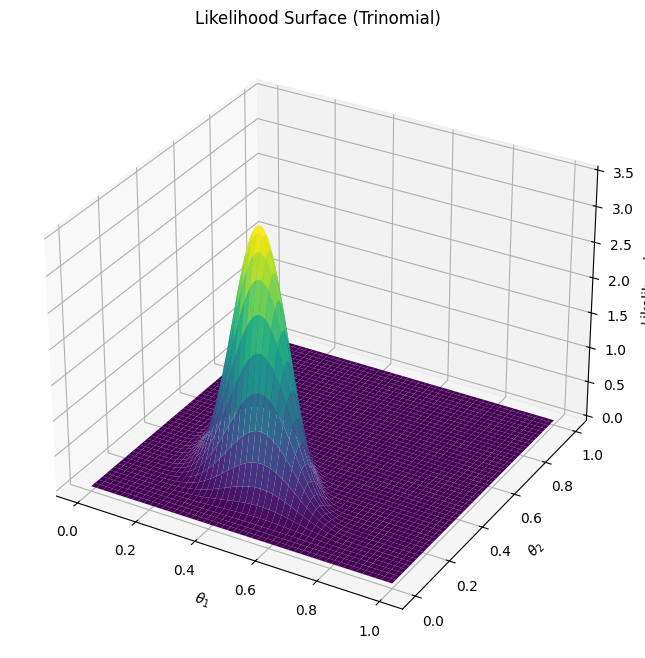

Theoretical binomial parameters by MLE: theta1_MLE = 0.4000, theta2_MLE = 0.3000
MLE estimate from plot: theta1_MLE = 0.3970, theta2_MLE = 0.3015


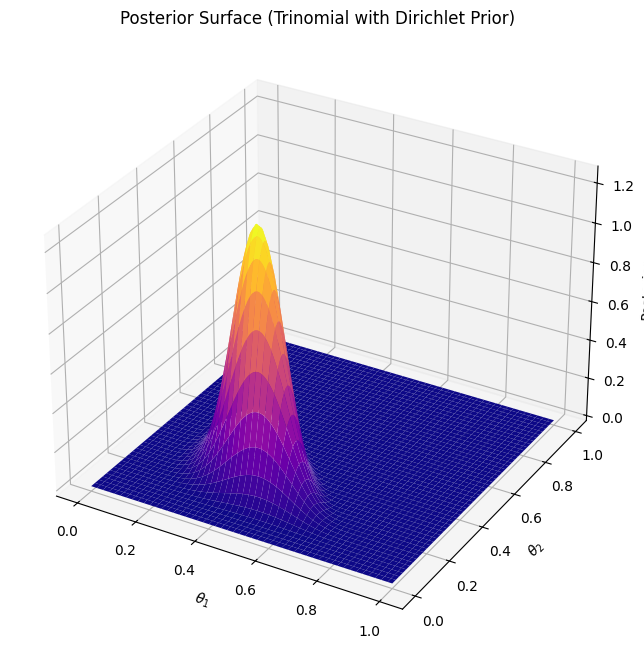

Theoretical binomial parameters by MAP: theta1_MAP = 0.3913, theta2_MAP = 0.3043
MAP estimate from plot: theta1_MAP = 0.3920, theta2_MAP = 0.3015

Comparison of Results:
MLE Theta1 (from plot): 0.3970, Theoretical MLE Theta1: 0.4000
MLE Theta2 (from plot): 0.3015, Theoretical MLE Theta2: 0.3000
MAP Theta1 (from plot): 0.3920, Theoretical MAP Theta1: 0.3913
MAP Theta2 (from plot): 0.3015, Theoretical MAP Theta2: 0.3043


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data: Number of trials and counts for each outcome
n = 20  # Total trials
k1, k2, k3 = 8, 6, 6  # Counts for each outcome (k1 + k2 + k3 = n)

# Generate values for theta1 and theta2, making sure theta3 = 1 - theta1 - theta2
theta1_values = np.linspace(0, 1, 200)
theta2_values = np.linspace(0, 1, 200)
theta1_grid, theta2_grid = np.meshgrid(theta1_values, theta2_values)
theta3_grid = 1 - theta1_grid - theta2_grid

# Likelihood: Trinomial distribution (ignoring the factorial terms, just focus on pdf shape)
likelihood = (theta1_grid**k1) * (theta2_grid**k2) * (theta3_grid**k3)
likelihood[theta3_grid < 0] = 0  # Ensure theta3 is non-negative

# 1. Plot the likelihood surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta1_grid, theta2_grid, likelihood, cmap='viridis')
ax.set_title('Likelihood Surface (Trinomial)')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel('Likelihood')
plt.show()

# Find MLE by argmax on the likelihood surface
max_likelihood_index = np.unravel_index(np.argmax(likelihood, axis=None), likelihood.shape)
mle_theta1_plot = theta1_grid[max_likelihood_index]
mle_theta2_plot = theta2_grid[max_likelihood_index]

# Theoretical MLE
theta1_mle = k1 / n
theta2_mle = k2 / n
print(f"Theoretical binomial parameters by MLE: theta1_MLE = {theta1_mle:.4f}, theta2_MLE = {theta2_mle:.4f}")
print(f"MLE estimate from plot: theta1_MLE = {mle_theta1_plot:.4f}, theta2_MLE = {mle_theta2_plot:.4f}")

# 2. Posterior with Dirichlet prior
alpha1, alpha2, alpha3 = 2, 2, 2  # Dirichlet prior parameters
posterior = (theta1_grid**(k1 + alpha1 - 1)) * (theta2_grid**(k2 + alpha2 - 1)) * (theta3_grid**(k3 + alpha3 - 1))
posterior[theta3_grid < 0] = 0  # Ensure theta3 is non-negative

# Plot the posterior surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta1_grid, theta2_grid, posterior, cmap='plasma')
ax.set_title('Posterior Surface (Trinomial with Dirichlet Prior)')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel('Posterior')
plt.show()

# Find MAP by argmax on the posterior surface
max_posterior_index = np.unravel_index(np.argmax(posterior, axis=None), posterior.shape)
map_theta1_plot = theta1_grid[max_posterior_index]
map_theta2_plot = theta2_grid[max_posterior_index]

# Theoretical MAP
theta1_map = (k1 + alpha1 - 1) / (n + alpha1 + alpha2 + alpha3 - 3)
theta2_map = (k2 + alpha2 - 1) / (n + alpha1 + alpha2 + alpha3 - 3)
print(f"Theoretical binomial parameters by MAP: theta1_MAP = {theta1_map:.4f}, theta2_MAP = {theta2_map:.4f}")
print(f"MAP estimate from plot: theta1_MAP = {map_theta1_plot:.4f}, theta2_MAP = {map_theta2_plot:.4f}")

# 3. Comparison of Results
print(f"\nComparison of Results:")
print(f"MLE Theta1 (from plot): {mle_theta1_plot:.4f}, Theoretical MLE Theta1: {theta1_mle:.4f}")
print(f"MLE Theta2 (from plot): {mle_theta2_plot:.4f}, Theoretical MLE Theta2: {theta2_mle:.4f}")
print(f"MAP Theta1 (from plot): {map_theta1_plot:.4f}, Theoretical MAP Theta1: {theta1_map:.4f}")
print(f"MAP Theta2 (from plot): {map_theta2_plot:.4f}, Theoretical MAP Theta2: {theta2_map:.4f}")

**4. Comparison of Results**
Compare the MLE and MAP estimates from the plots with the theoretical estimates from both the flat prior and the altered prior. Discuss how the changes in the prior belief affect the MAP estimates.

When I used the uniform prior of [2, 2, 2], I started with the assumption that all three outcomes had an equal chance of happening. Because this was a neutral starting point, my final MAP estimates ended up being almost identical to my raw data. The prior basically just smoothed the numbers out a tiny bit without making any drastic changes. However, when I switched to the altered prior of [1, 2, 1], I changed my initial assumption to strongly favor Outcome 2. Since my dataset was pretty small at only 20 trials, this initial bias made a noticeable difference, successfully pulling my final estimate for θ subscript
2 up while pushing θ subscript 1 down. Ultimately, this comparison showed me that MAP estimation is essentially a tug-of-war between my initial assumptions and the actual evidence. Because I didn't have a lot of data points, those initial assumptions were strong enough to noticeably shift the final results away from the raw data.